# Credit Card Users Churn Prediction

Customers’ leaving credit cards services would lead bank to loss, so the bank wants to analyze the data of customers and identify the customers who will leave their credit card services and reason for same, so that bank could improve upon those areas.

### Objectives:

1. Explore and visualize the dataset.
2. Build a classification model to predict if the customer is going to churn or not.
3. Optimize the model using appropriate techniques.
4. Generate a set of insights and recommendations that will help the bank.


### Data Dictionary:

- CLIENTNUM: Client number. Unique identifier for the customer holding the account
- Attrition_Flag: Internal event (customer activity) variable - if the account is closed then "Attrited Customer" else "Existing Customer"
- Customer_Age: Age in Years
- Gender: Gender of the account holder
- Dependent_count: Number of dependents
- Education_Level:  Educational Qualification of the account holder - Graduate, High School, Unknown, Uneducated, College(refers to a college student), Post-Graduate, Doctorate.
- Marital_Status: Marital Status of the account holder
- Income_Category: Annual Income Category of the account holder
- Card_Category: Type of Card
- Months_on_book: Period of relationship with the bank
- Total_Relationship_Count: Total no. of products held by the customer
- Months_Inactive_12_mon: No. of months inactive in the last 12 months
- Contacts_Count_12_mon: No. of Contacts between the customer and bank in the last 12 months
- Credit_Limit: Credit Limit on the Credit Card
- Total_Revolving_Bal: The balance that carries over from one month to the next is the revolving balance
- Avg_Open_To_Buy: Open to Buy refers to the amount left on the credit card to use (Average of last 12 months)
- Total_Trans_Amt: Total Transaction Amount (Last 12 months)
- Total_Trans_Ct: Total Transaction Count (Last 12 months)
- Total_Ct_Chng_Q4_Q1: Ratio of the total transaction count in 4th quarter and the total transaction count in 1st quarter
- Total_Amt_Chng_Q4_Q1: Ratio of the total transaction amount in 4th quarter and the total transaction amount in 1st quarter
- Avg_Utilization_Ratio: Represents how much of the available credit the customer spent

## Imorting Liabraries

In [ ]:
# Mount the drive to google drive to get data set from it
from google.colab import drive
drive.mount('/content/drive/')

# from os library change the directory to the data place directory  to read the data
import os
os.chdir('/content/drive/My Drive/colab/')

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
# Libraries to help with data visualization
import seaborn as sns
import matplotlib.pyplot as plt
# Library of warning to check errors
import warnings
warnings.filterwarnings('ignore')

# Libraries to help in building models

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split # Sklearn package's randomized data splitting function
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Command to tell Python to actually display the graphs
%matplotlib inline

# Removes the limit from the number of displayed columns and rows.
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

Mounted at /content/drive/


In [ ]:
# To get different performance metrics
import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    accuracy_score,
    precision_score,
    f1_score,
)

### Reading Data

In [ ]:
# read the data from the file and assign it into variable data
data = pd.read_csv("BankChurners.csv")
# I'm now going to look at 10 random rows
# I'm setting the random seed via np.random.seed so that
# I get the same random results every time
np.random.seed(1)
data.sample(n=10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
6498,712389108,Existing Customer,43,F,2,Graduate,Married,Less than $40K,Blue,36,6,3,2,2570.0,2107,463.0,0.651,4058,83,0.766,0.820
9013,718388733,Existing Customer,38,F,1,College,NaN,Less than $40K,Blue,32,2,3,3,2609.0,1259,1350.0,0.871,8677,96,0.627,0.483
2053,710109633,Existing Customer,39,M,2,College,Married,$60K - $80K,Blue,31,6,3,2,9871.0,1061,8810.0,0.545,1683,34,0.478,0.107
3211,717331758,Existing Customer,44,M,4,Graduate,Married,$120K +,Blue,32,6,3,4,34516.0,2517,31999.0,0.765,4228,83,0.596,0.073
5559,709460883,Attrited Customer,38,F,2,Doctorate,Married,Less than $40K,Blue,28,5,2,4,1614.0,0,1614.0,0.609,2437,46,0.438,0.000
6106,789105183,Existing Customer,54,M,3,Post-Graduate,Single,$80K - $120K,Silver,42,3,1,2,34516.0,2488,32028.0,0.552,4401,87,0.776,0.072
4150,771342183,Attrited Customer,53,F,3,Graduate,Single,$40K - $60K,Blue,40,6,3,2,1625.0,0,1625.0,0.689,2314,43,0.433,0.000
2205,708174708,Existing Customer,38,M,4,Graduate,Married,$40K - $60K,Blue,27,6,2,4,5535.0,1276,4259.0,0.636,1764,38,0.900,0.231
4145,718076733,Existing Customer,43,M,1,Graduate,Single,$60K - $80K,Silver,31,4,3,3,25824.0,1170,24654.0,0.684,3101,73,0.780,0.045
5324,821889858,Attrited Customer,50,F,1,Doctorate,Single,abc,Blue,46,6,4,3,1970.0,1477,493.0,0.662,2493,44,0.571,0.750


In [ ]:
#Remove the client number from the data set
data.drop('CLIENTNUM', axis=1, inplace=True)
#Get the data information and check the missing data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           8608 non-null   object 
 5   Marital_Status            9378 non-null   object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

Observation:
Tow columns have missing data education level and Marital status.
But above there is missing information in rows of the data:
- Income_Category : has value of 'abc'
- Marital_Status : has value of NAN
- Total_Revolving_Bal : has value of 0 in some rows

it seems that only tow columns have missing data, but there are another rows that have no meaning data..

I will try to fix it..

## Univariate analysis - Bivariate analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7fe1b9f20850>,
      dtype=object)

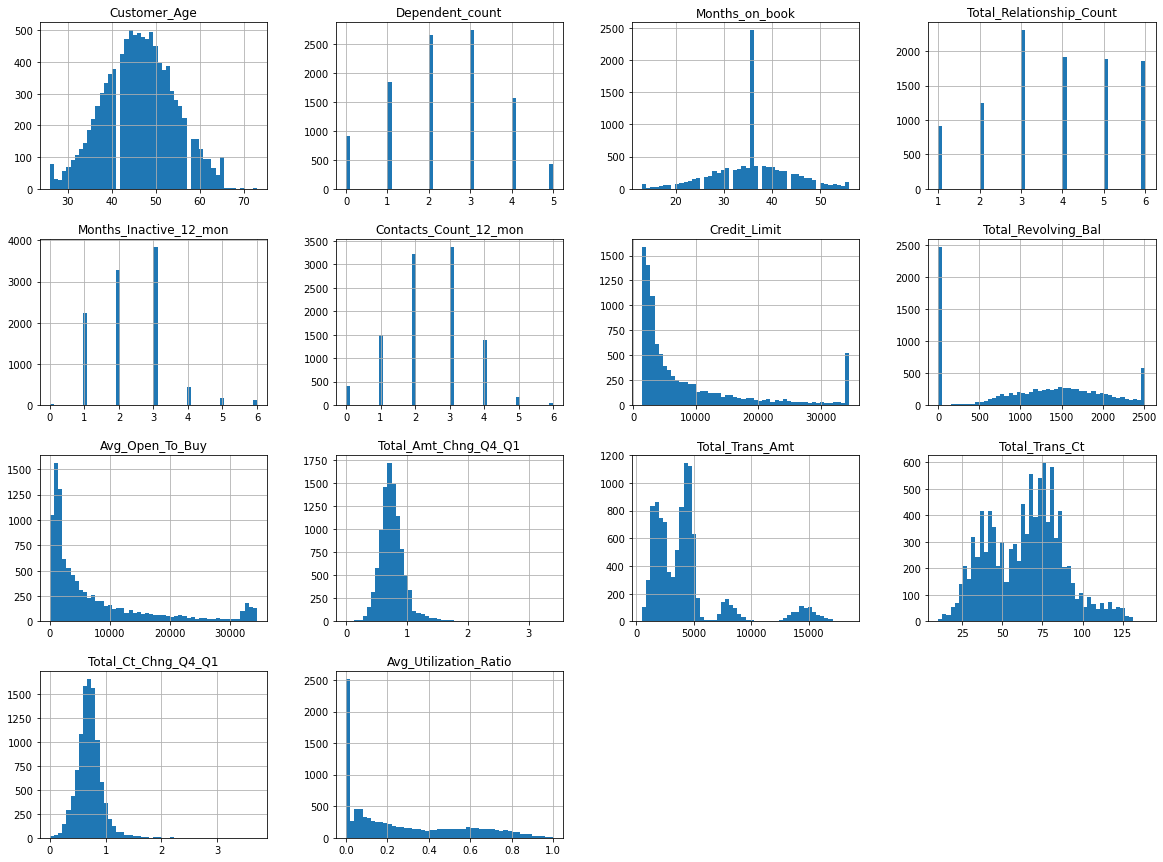

In [ ]:
# See the histogram of numberical data
data.hist(bins=50, figsize=(20,15))

In Customer_Age : It is normally distributed with mean and median at 46 years.

In Months_On_Books : Most customers are with the bank for 2 years.

In Credit_Limit : It is skewed to the right. There are quite a few customers with a maximum Credit Limit of 35000.
50% of the customers of the bank have a credit limit of less than <10000.

In Total_Revolving_Bal : Most customers complete dues of credit card and have 0 revolving balance. There are few customers with a revolving balance of 2500.

In Avg_Open_To_Buy : It is right-skewed. A right-skewed indicates that most customers used a big part of their limit while only a few customers were left in the right tail ( not using their credit cards).

In Total_Amt_Chng_Q4_Q1 : It looks normally distributed but there's a slight skew towards the right.

In Total_Trans_Amt : It is skewed to the right. There are two peaks in data at total transaction amounts of one around 2500 and the second around the mean value of 4500.

In Total_Trans_Ct : It shows two peaks on 40 and 75 transactions in a year which indicates that customers used credit cards in at least 3 times per month

In Total_Ct_Chng_Q4_Q1 : It looks normally distributed but there's a slight skew towards the right.

In Avg_Utilization_Ratio : It skewed to the right. It is not a positive sign for the bank as most of the customers are not utilizing their credit amount.

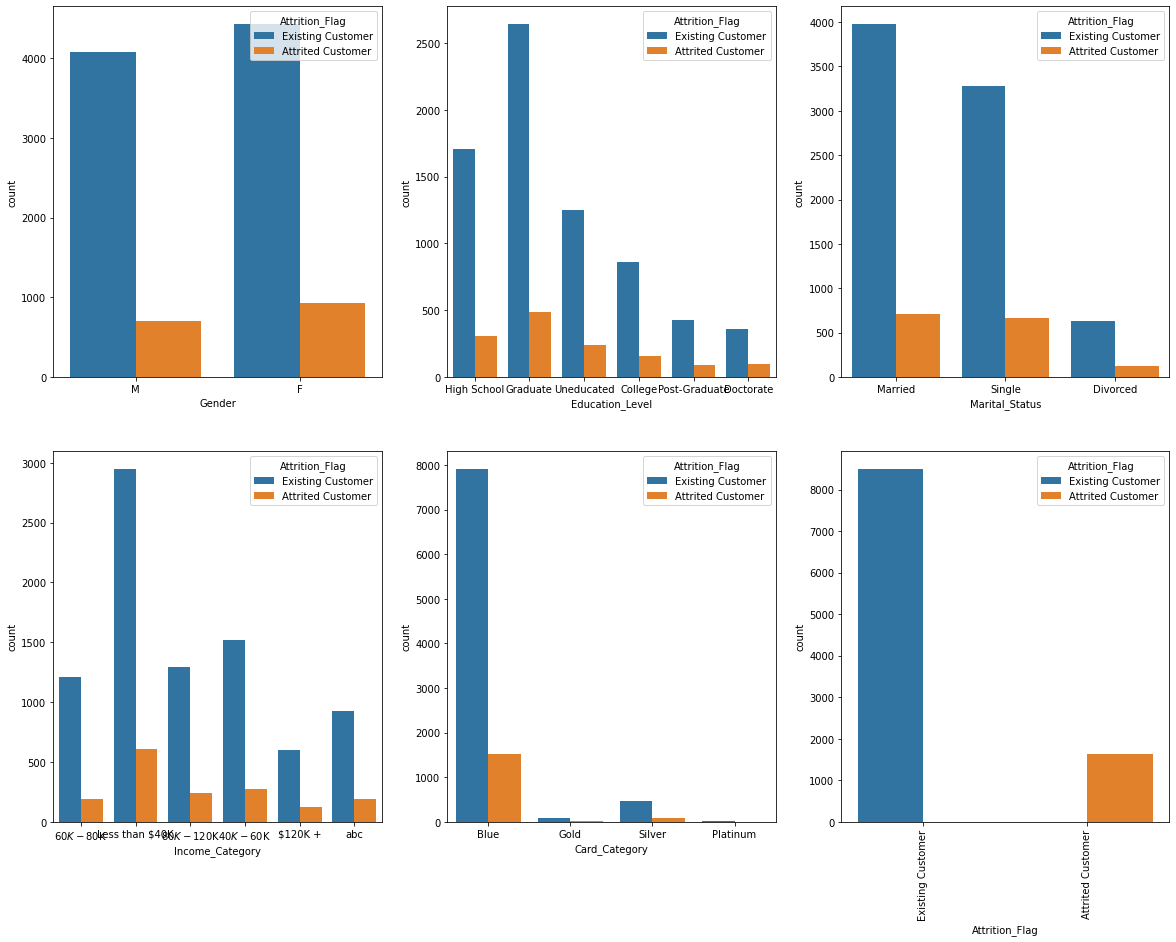

In [ ]:
cat_features = data[[ 'Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Attrition_Flag']]
import seaborn as sns
fig , ax = plt.subplots(2,3,figsize = (20,15))
    # set up 2 x 3 frame count plot with figsize 20 x 15
for i , subplots in zip (cat_features, ax.flatten()):
  sns.countplot(cat_features[i],hue = data['Attrition_Flag'],ax = subplots)
plt.xticks(rotation=90)
plt.show()

Draw figures of each catgorical feature. Attrited vs Exsiting to see the difference.

In Gender : There's not much difference in attrition percentages for Males and Females. About 20% of both Males and Females attrite.

In Education_Level : Higher education post graduate are the ones most, about 20% for both education levels attriting.

In Marital_Status: There's not much difference in attrition , only the divorced alittle bit smaller, about 20% of Singles, Marrid attrite.

In Income_Category : The customers from income group less than 40K are the ones attriting the most.

In Card Category : Customers with Platinum and Gold cards are our premium customers. No attriting from this group platinum group.


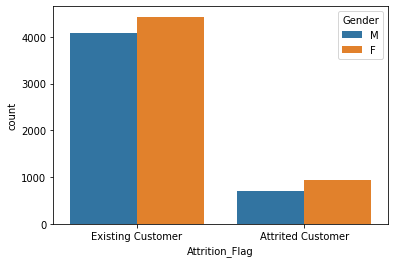

In [ ]:
# See distribution of categrorical varaible Attrition_Flag
sns.countplot(data=data, x='Attrition_Flag', hue='Gender');

Female are the most good customer as existing customers and also as attrited customers.

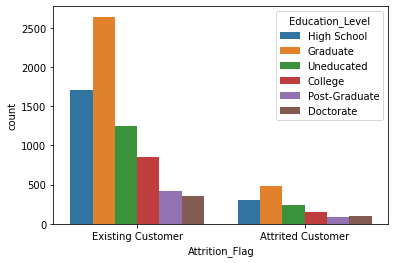

In [ ]:
# See distribution of categrorical varaible Education_Level
sns.countplot(data=data, x='Attrition_Flag', hue='Education_Level');

Customers with lower education are the ones most attriting.

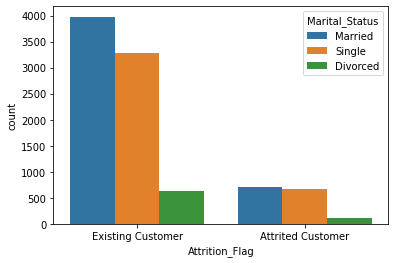

In [ ]:
# See distribution of categrorical varaible Marital_Status
sns.countplot(data=data, x='Attrition_Flag', hue='Marital_Status');

There's not much difference in attrition percentages for Marital_Status Married and Single. Divorced attrite attrite the least.

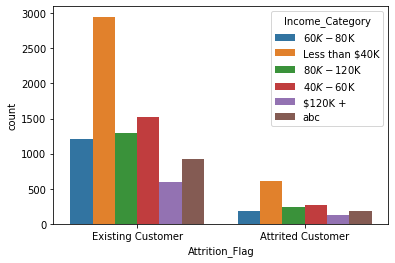

In [ ]:
# See distribution of categrorical varaible Income_Category
sns.countplot(data=data, x='Attrition_Flag', hue='Income_Category');

The customers from two extreme income groups - Earning less than 40K attriting the most. and the customers earning more than 120k+ are the ones keep their bank product the most

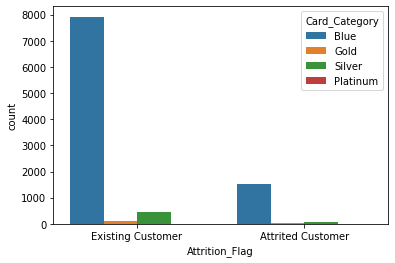

In [ ]:
# See distribution of categrorical varaible Card_Category
sns.countplot(data=data, x='Attrition_Flag', hue='Card_Category');

Customers with blue cards are the highest. Cutsomers with Platinum and Gold cards will be our premium customers and the highest attrition for these customers warns us, becuse they are little number of them

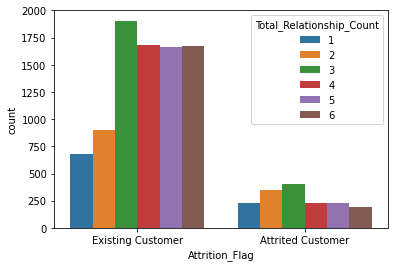

In [ ]:
# See distribution of categrorical varaible Card_Category
sns.countplot(data=data, x='Attrition_Flag', hue='Total_Relationship_Count');

Attrition is highest among the customers who are using 2 or 3 products offered by the bank.

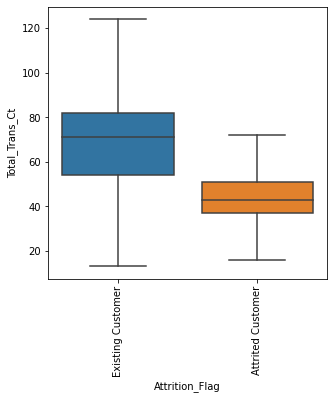

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,x='Attrition_Flag',y='Total_Trans_Ct',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

A few customers attrited according to feature of total_trans_ct. It affect the attrited customers in small values

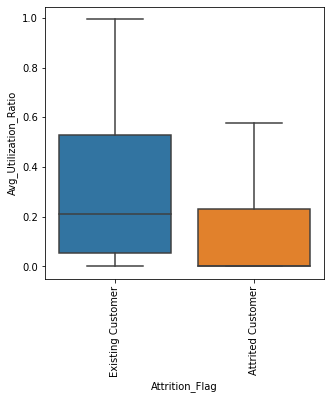

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,x='Attrition_Flag',y='Avg_Utilization_Ratio',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

Attrited customers are less than the existing customers here. So this feature affects the attriting little bit.

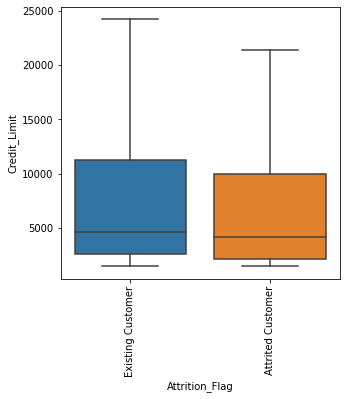

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,x='Attrition_Flag',y='Credit_Limit',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

There are quite a few customers with a maximum Credit Limit of 25000.
50% of the customers of the bank have a credit limit of less than <5000. That means this distribution is skweed to the right

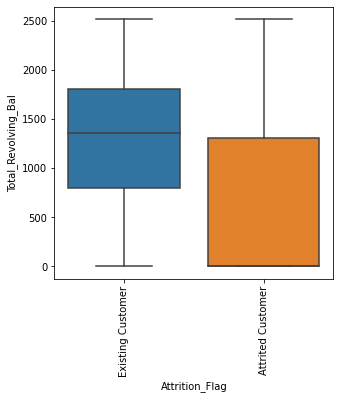

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,x='Attrition_Flag',y='Total_Revolving_Bal',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

Observations on Total_Revolving_Bal: Customers with less total revolving balance are the ones who attrited. Bank can ask for reasons from their experience of why they got attriited.

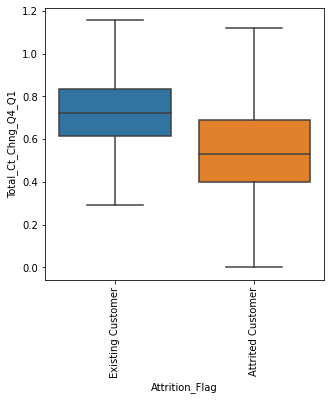

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,x='Attrition_Flag',y='Total_Ct_Chng_Q4_Q1',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

Number of attrited customers is aobut 0.4 to 0.6, This featuer affect attriting.

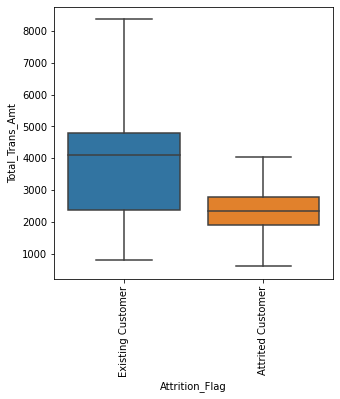

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,x='Attrition_Flag',y='Total_Trans_Amt',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

Totoal transaction amount shows little attriting customers and large box for existing customers. It also low in scale.

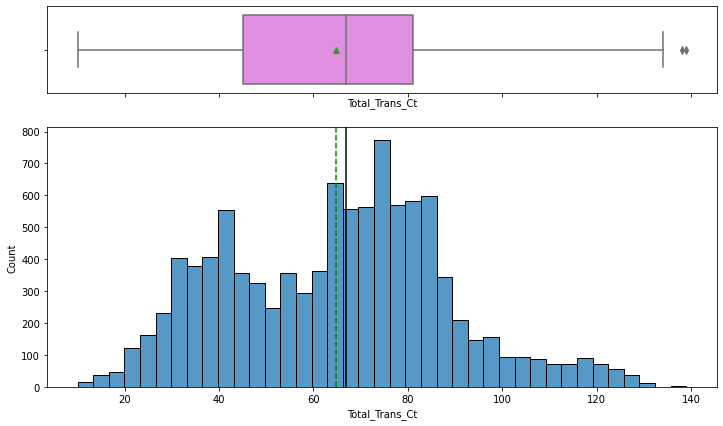

In [ ]:
# See the distribution of Total_Trans_Ct to recognize different distributions
histogram_boxplot(data, "Total_Trans_Ct")

The distribution of Total_Trans_Ct shows two peaks on 40 and 80 transactions in a year which indicates that customers used credit cards 3 to 6 times a month to make transactions.

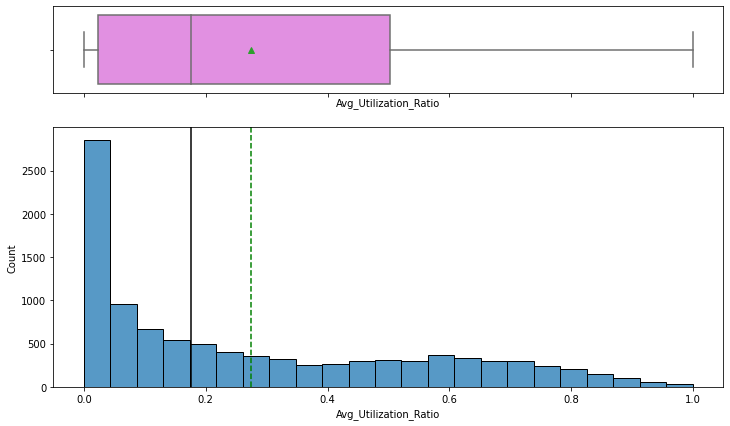

In [ ]:
# See the distribution of Avg_Utilization_Ratio to recognize different distributions
histogram_boxplot(data, "Avg_Utilization_Ratio")

Observation:
It highly skweed to the right, it shows that most data points have 0 values. No outliers in the box plot

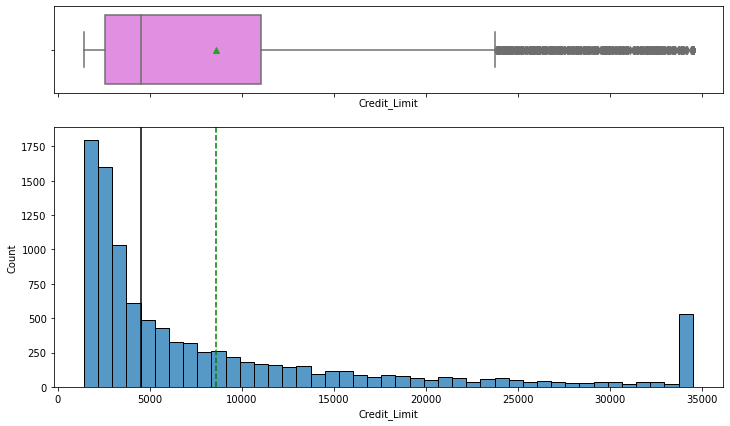

In [ ]:
# See the distribution of Credit_Limit to recognize different distributions
histogram_boxplot(data, "Credit_Limit")

Observation: It highly skweed to the right. most of credit limits data points tends to 0. but some data points have 35000 credit limits.

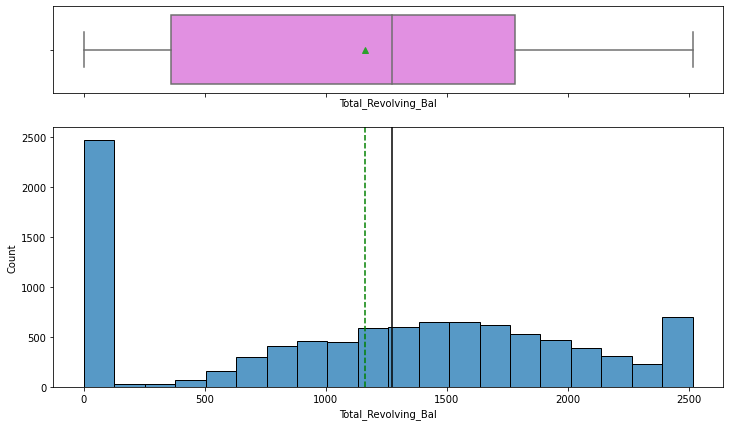

In [ ]:
# See the distribution of Total_Revolving_Bal to recognize different distributions
histogram_boxplot(data, "Total_Revolving_Bal")

Observations:
There are lots of values within 0 region. But the other values set between 500 and 2500. The relation between right skewed histogram mean, median, and mode is Mean > Median > Mode. The peak of the graph lies on the left side of the center. Mean is approximatly is 1201, Median is 1301. So it is not right skweed histogram.

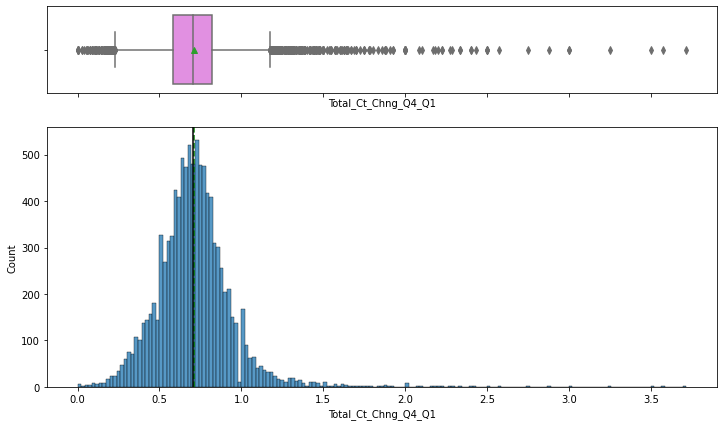

In [ ]:
# See the distribution of Total_Ct_Chng_Q4_Q1 to recognize different distributions
histogram_boxplot(data, "Total_Ct_Chng_Q4_Q1")

Observation: not skweed , it is in the center, good graph. but it   shows that there are many outliers to the right. These outliers let the graph to be skweed to the right.

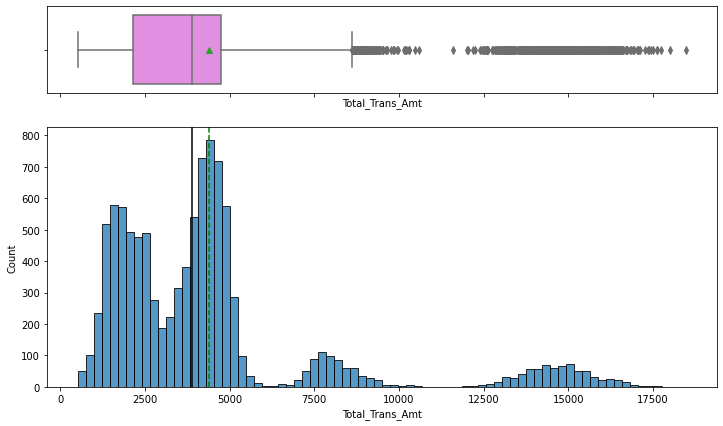

In [ ]:
# See the distribution of Total_Trans_Amt to recognize different distributions
histogram_boxplot(data, "Total_Trans_Amt")

Observations: It is skweed to the right. but most data points set between 0 to 5000. Less transactions amount can lead to less transaction number and then lead to attrition.





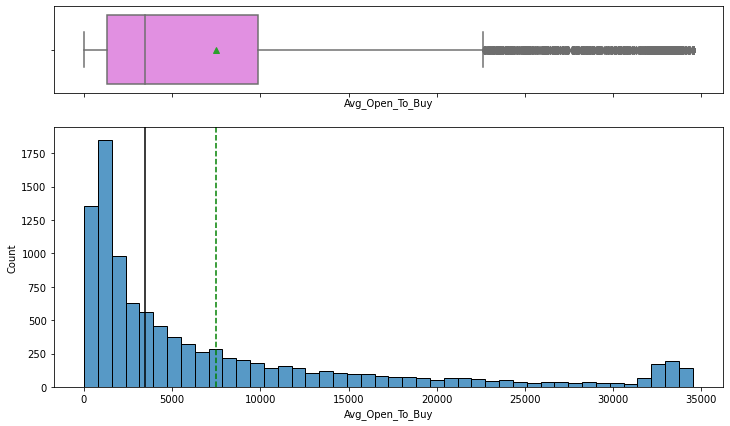

In [ ]:
# See the distribution of Avg_Open_To_Buy to recognize different distributions
histogram_boxplot(data, "Avg_Open_To_Buy")

Observation: Highly Skweed to right, right-skewed distribution indicates that most customers used a big part of their limit while only a few customers (on the right tail) were left with a majority of their credit amount.

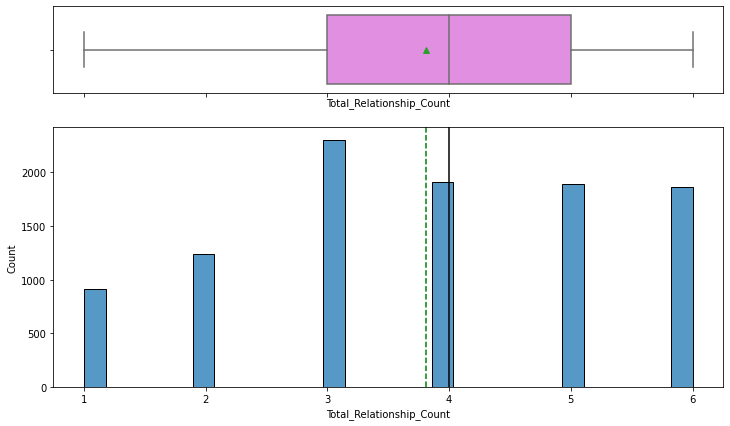

In [ ]:
# See the distribution of Total_Relationship_Count to recognize different distributions
histogram_boxplot(data, "Total_Relationship_Count")

Observations: The most frequent ( mode ) of the product that used by the customer is 3 product. But we can see that the median and mean are near to each other. Median is 4. Mean is about 3.9. No outliers in this coulmn ( feature ).

### Bivariate Analysis

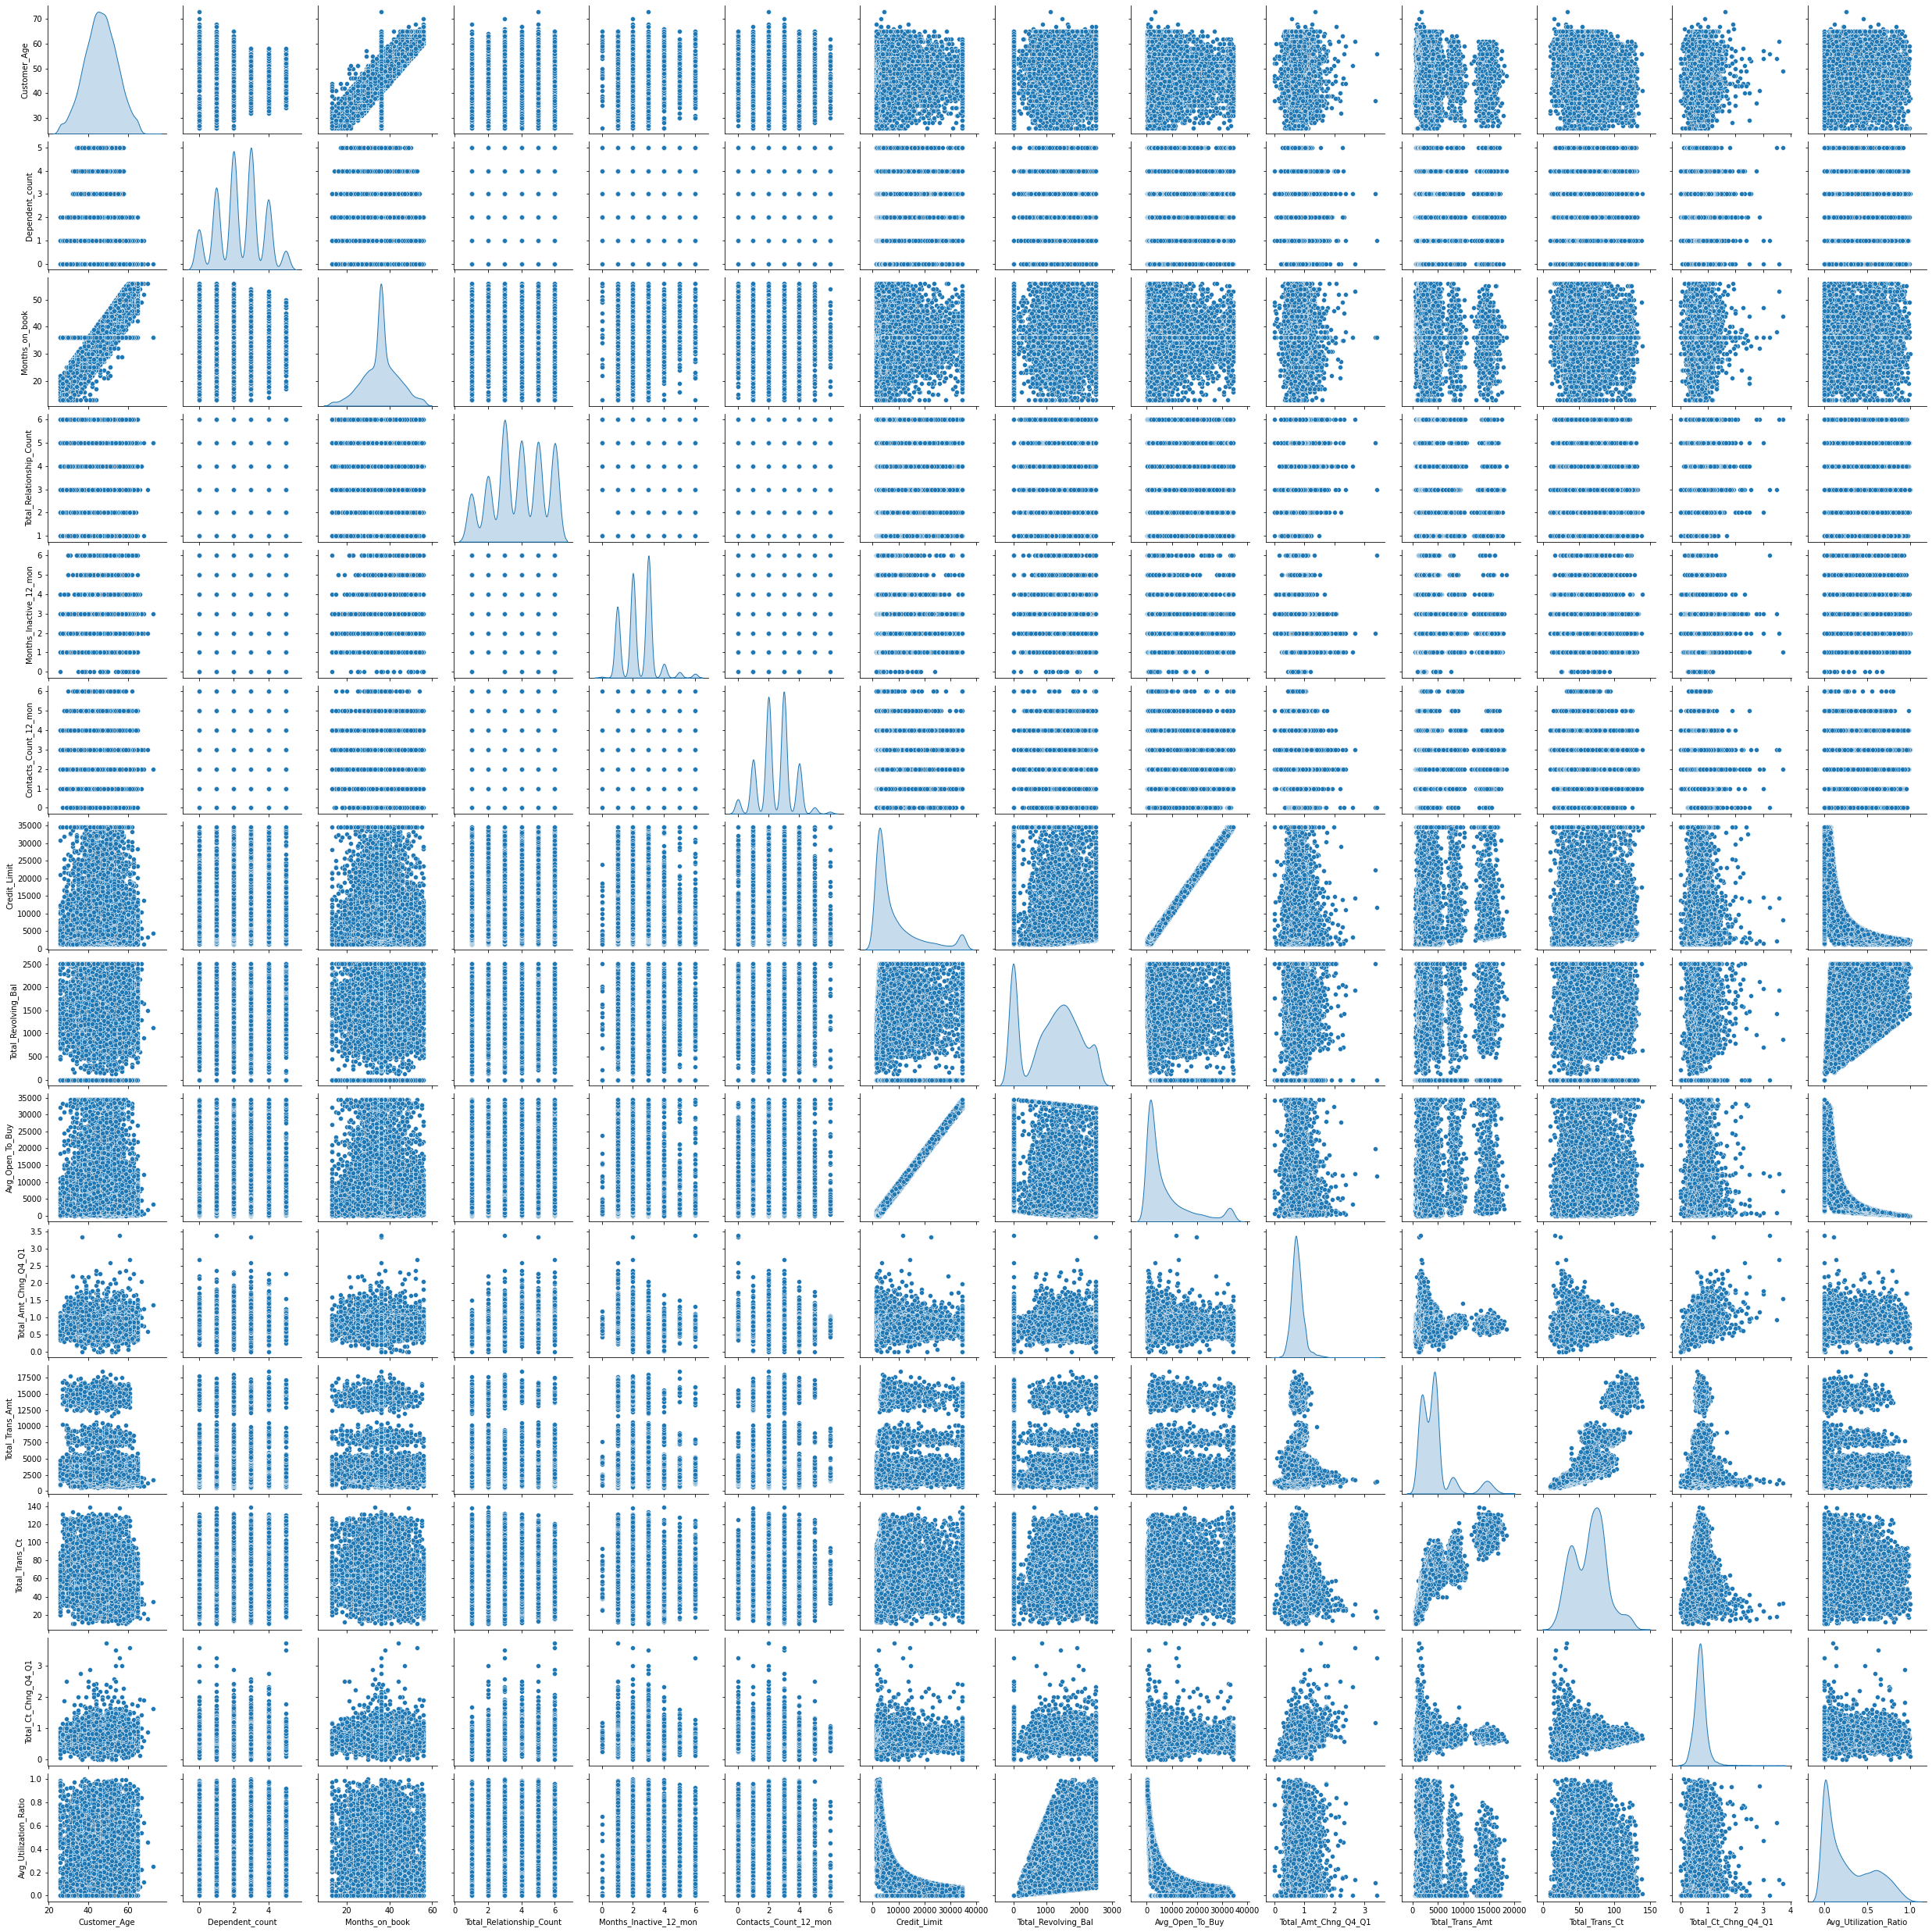

In [ ]:
sns.pairplot(data, diag_kind='kde')

Observations: There are positive relationship between variables

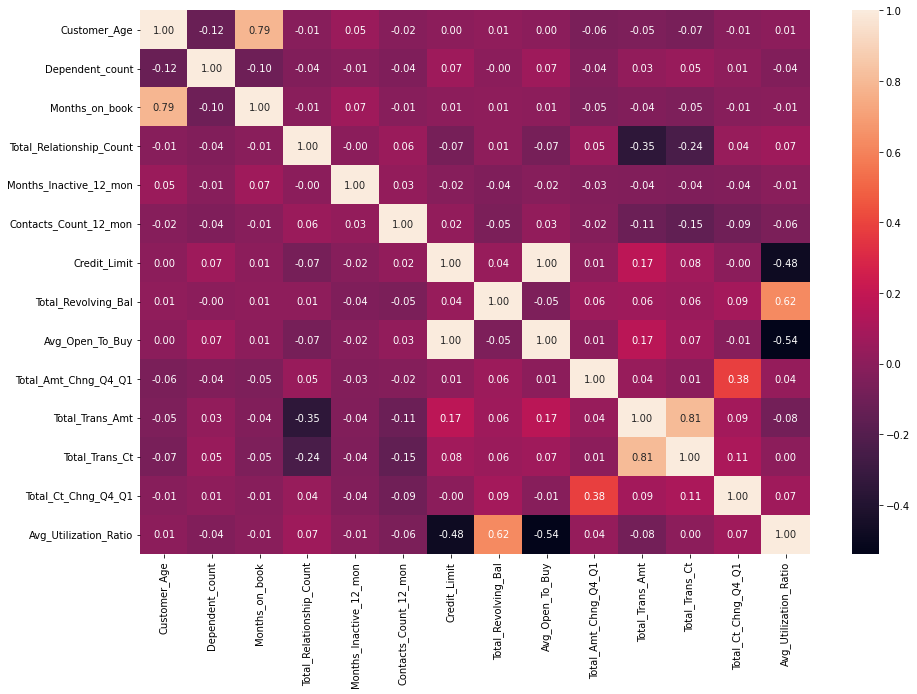

In [ ]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(), annot=True, fmt=".2f")
plt.show()

#Preprocessing
###  **Income_Category**

In [ ]:
data['Income_Category'].value_counts()

Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
abc               1112
$120K +            727
Name: Income_Category, dtype: int64

there are about 1112 rows have value of abc and the others I will ceil it to lower one like 40k - 60k will be 40000 and so on.

In [ ]:
# create a function to change values of string to float
def value_to_float(x):

    if 'Less than $40K' in x:
        if len(x) > 1:
            return float(x.replace('Less than $40K', '30')) * 1000

    if '$40K - $60K' in x:
        if len(x) > 1:
            return float(x.replace('$40K - $60K', '40')) * 1000

    if '$80K - $120K' in x:
        if len(x) > 1:
            return float(x.replace('$80K - $120K', '80')) * 1000

    if '$120K +' in x:
        if len(x) > 1:
            return float(x.replace('$120K +', '120')) * 1000

    if '$60K - $80K' in x:
        return float(x.replace('$60K - $80K', '60')) * 1000



data['Income_Category'] = data['Income_Category'].apply(value_to_float)


In [ ]:
data.isnull().sum()

Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status               749
Income_Category             1112
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
dtype: int64

In [ ]:
# fill the abc values with mode
data['Income_Category'].fillna(data['Income_Category'].mode()[0], inplace = True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  int64  
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           8608 non-null   object 
 5   Marital_Status            9378 non-null   object 
 6   Income_Category           10127 non-null  float64
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

### Marital_Status

import impute to impute this column with the most frequent value

In [ ]:
data['Marital_Status'].value_counts()

Married     4687
Single      3943
Divorced     748
Name: Marital_Status, dtype: int64

In [ ]:
# import libraries
from sklearn.impute import SimpleImputer
from numpy import isnan
# defining the imputer
value = data['Marital_Status'].values
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# transform the dataset
data['Marital_Status'] = imputer.fit(data[['Marital_Status']])
imputer.transform(data[['Marital_Status']])


array([[SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')],
       ...,
       [SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')]], dtype=object)

In [ ]:
data.isnull().sum()

Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status                 0
Income_Category                0
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
dtype: int64

### Education_Level

In [ ]:
# defining the imputer
value = data['Education_Level'].values
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

# transform the dataset
data['Education_Level'] = imputer.fit(data[['Education_Level']])
imputer.transform(data[['Education_Level']])

array([[SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')],
       ...,
       [SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')],
       [SimpleImputer(strategy='most_frequent')]], dtype=object)

### Total_Revolving_Bal
rplace value of 0 to mean of this column. I choose the mean because it will not skweed the data from left or right. Mode may skweed the data to left or right.

In [ ]:
data['Total_Revolving_Bal'].replace(0,data['Total_Revolving_Bal'].mean(axis=0),inplace=True)

### Attrition_Flag ( my interest variable )

In [ ]:
data["Attrition_Flag"].replace(('Existing Customer', 'Attrited Customer'), (1, 0), inplace=True)

### One hot Encoding for categorical variables
Do one hot coding

In [ ]:
data = pd.get_dummies(data, columns=["Card_Category","Marital_Status","Education_Level","Gender"])

# EDA

In [ ]:
#find the shape of the data
print(f'There are {data.shape[0]} rows and {data.shape[1]} columns.')  # f-string

There are 10127 rows and 24 columns.


Observation:
I have good shape of the data, I do not need oversapmling or downsampling.

In [ ]:
data.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,10127.0,0.839340,0.367235,0.0,1.000000,1.000,1.000,1.000
Customer_Age,10127.0,46.325960,8.016814,26.0,41.000000,46.000,52.000,73.000
Dependent_count,10127.0,2.346203,1.298908,0.0,1.000000,2.000,3.000,5.000
Income_Category,10127.0,49960.501629,26539.474177,30000.0,30000.000000,40000.000,60000.000,120000.000
Months_on_book,10127.0,35.928409,7.986416,13.0,31.000000,36.000,40.000,56.000
Total_Relationship_Count,10127.0,3.812580,1.554408,1.0,3.000000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.0,2.341167,1.010622,0.0,2.000000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.0,2.455317,1.106225,0.0,2.000000,2.000,3.000,6.000
Credit_Limit,10127.0,8631.953698,9088.776650,1438.3,2555.000000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.0,1446.427247,503.922618,132.0,1162.814061,1276.000,1784.000,2517.000


In [ ]:
#get the data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 24 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Attrition_Flag                                           10127 non-null  int64  
 1   Customer_Age                                             10127 non-null  int64  
 2   Dependent_count                                          10127 non-null  int64  
 3   Income_Category                                          10127 non-null  float64
 4   Months_on_book                                           10127 non-null  int64  
 5   Total_Relationship_Count                                 10127 non-null  int64  
 6   Months_Inactive_12_mon                                   10127 non-null  int64  
 7   Contacts_Count_12_mon                                    10127 non-null  int64  
 8   Credit_Limit              

In [ ]:
data.duplicated().sum() # check if any duplicates in the data

0

## Model building
Choose metric on interest - Build 6 models (from logistic regression, decision trees, bagging and boosting methods) Note: You can choose not to build XGBoost if you are facing issues with the installation

In [ ]:
data = data.astype('float32') # to make sure that all the data is readable by model
X = data.drop('Attrition_Flag',axis=1)     # Predictor feature columns (8 X m)
Y = data['Attrition_Flag']   # Predicted class (1=True, 0=False) (1 X m)

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
# 1 is just any random seed number

x_train.head()

,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Card_Category_Blue,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver,Marital_Status_SimpleImputer(strategy='most_frequent'),Education_Level_SimpleImputer(strategy='most_frequent'),Gender_F,Gender_M
8284,45.0,4.0,30000.0,40.0,1.0,2.0,1.0,1795.0,1058.000000,737.0,0.778,5575.0,73.0,0.738,0.589,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
9863,29.0,1.0,30000.0,36.0,4.0,3.0,2.0,3839.0,1139.000000,2700.0,0.632,14791.0,124.0,0.771,0.297,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
5350,55.0,2.0,30000.0,36.0,4.0,3.0,2.0,10241.0,1545.000000,8696.0,0.581,2513.0,47.0,0.424,0.151,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
9641,51.0,3.0,30000.0,33.0,3.0,3.0,3.0,7428.0,1162.814087,7428.0,0.873,8078.0,62.0,0.722,0.000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
5914,47.0,3.0,30000.0,31.0,5.0,1.0,3.0,2317.0,1162.814087,2317.0,0.570,4894.0,89.0,0.854,0.000,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0


In [ ]:
y_train.head()

8284    1.0
9863    1.0
5350    0.0
9641    0.0
5914    1.0
Name: Attrition_Flag, dtype: float32

In [ ]:
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(x_train)
    pred_test = model.predict(x_test)

    #Accuracy of the model
    train_acc = model.score(x_train,y_train)
    test_acc = model.score(x_test,y_test)

    #Recall of the model
    train_recall = metrics.recall_score(y_train,pred_train)
    test_recall = metrics.recall_score(y_test,pred_test)

    #Precision of the model
    train_precision = metrics.precision_score(y_train,pred_train)
    test_precision = metrics.precision_score(y_test,pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(x_train,y_train))
        print("Accuracy on test set : ",model.score(x_test,y_test))
        print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(y_test,pred_test))

    return score_list # returning the list with train and test scores

In [ ]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(x_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

### *Decision Tree model*

In [ ]:
dt_model = DecisionTreeClassifier(criterion = 'entropy' )
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
dt_model.score(x_test , y_test)
dt_mode_estimator_score=get_metrics_score(dt_model)

Accuracy on training set :  1.0
Accuracy on test set :  0.9427443237907206
Recall on training set :  1.0
Recall on test set :  0.9702077616620933
Precision on training set :  1.0
Precision on test set :  0.961912164788185


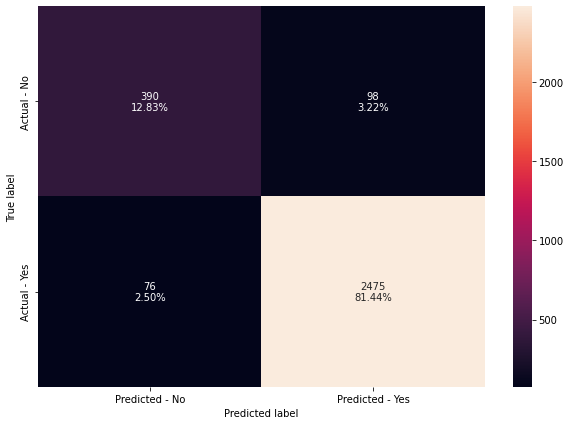

In [ ]:
y_predict = dt_model.predict(x_test)
make_confusion_matrix(dt_model,y_test)


### *Bagging* *Model*

In [ ]:
#base_estimator for bagging classifier is a decision tree by default
bagging_estimator=BaggingClassifier(random_state=1)
bagging_estimator.fit(x_train,y_train)

BaggingClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_estimator_score=get_metrics_score(bagging_estimator)

Accuracy on training set :  0.9976015801354402
Accuracy on test set :  0.9585389930898321
Recall on training set :  0.9979828542612204
Recall on test set :  0.9772638181105449
Precision on training set :  0.9991585324806462
Precision on test set :  0.9734478719250292


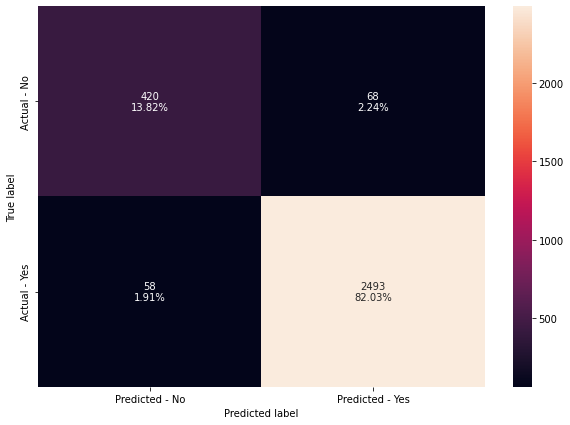

In [ ]:
make_confusion_matrix(bagging_estimator,y_test)

### *Random* *Forest Model*

In [ ]:
#Train the random forest classifier
rf_estimator=RandomForestClassifier(random_state=1)
rf_estimator.fit(x_train,y_train)

RandomForestClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
rf_estimator_score=get_metrics_score(rf_estimator)

Accuracy on training set :  1.0
Accuracy on test set :  0.9568937150378414
Recall on training set :  1.0
Recall on test set :  0.9890239121912975
Precision on training set :  1.0
Precision on test set :  0.9607768469154607


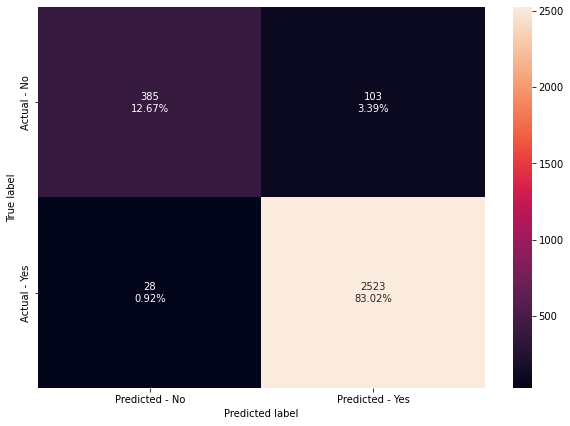

In [ ]:
make_confusion_matrix(rf_estimator,y_test)

With default parameters:

Random forest classifier is overfitting the train data.
Performance in terms of accuracy but bagging classifier is giving better recall.

### *Logistic* *Regression* *Model*

In [ ]:
from sklearn.linear_model import LogisticRegression

# Fit the model on train
model_lr = LogisticRegression(solver="liblinear", random_state=1)
model_lr.fit(x_train, y_train)
#predict on test
y_predict = model_lr.predict(x_test)


coef_df = pd.DataFrame(model_lr.coef_)
coef_df['intercept'] = model_lr.intercept_
print(coef_df)

          0         1             2         3         4         5         6  \
0 -0.019427 -0.090198 -1.263992e-07 -0.006558  0.163677 -0.144056 -0.170591   

          7         8         9        10        11        12        13  \
0  0.001735 -0.001791 -0.001731  0.017356 -0.000406  0.098633  0.052651   

         14        15        16        17        18      19      20        21  \
0 -0.006483 -0.005392 -0.004163 -0.001092 -0.001853 -0.0125 -0.0125 -0.043469   

         22  intercept  
0  0.030969    -0.0125  


In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
lr_estimator_score=get_metrics_score(model_lr)

Accuracy on training set :  0.8882618510158014
Accuracy on test set :  0.8881210924646266
Recall on training set :  0.9719280551353169
Recall on test set :  0.9717757742061937
Precision on training set :  0.9024504448259716
Precision on test set :  0.9024390243902439


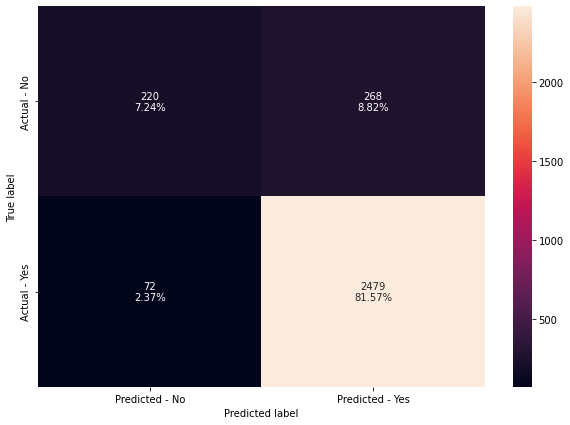

In [ ]:
make_confusion_matrix(model_lr,y_test)

### *Boosting Model*

In [ ]:
abc = AdaBoostClassifier(random_state=1)
abc.fit(x_train,y_train)

AdaBoostClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
abc_score=get_metrics_score(abc)

Accuracy on training set :  0.9643058690744921
Accuracy on test set :  0.9522869364922671
Recall on training set :  0.9843671205244579
Recall on test set :  0.9831438651509212
Precision on training set :  0.973404255319149
Precision on test set :  0.960919540229885


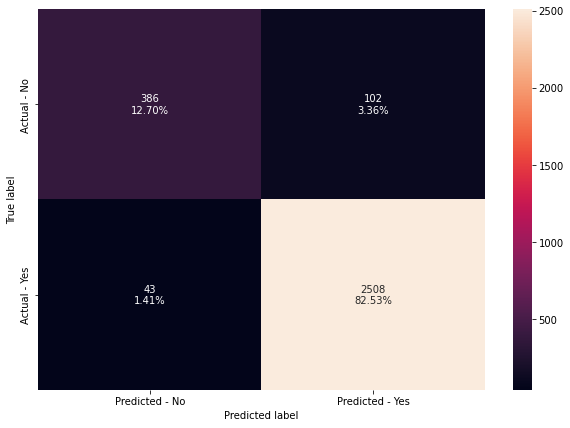

In [ ]:
make_confusion_matrix(abc,y_test)

### *Baggin Logistic Regression*

In [ ]:
bagging_lr=BaggingClassifier(base_estimator=LogisticRegression(solver='liblinear',random_state=1,max_iter=1000),random_state=1)
bagging_lr.fit(x_train,y_train)

BaggingClassifier(base_estimator=LogisticRegression(max_iter=1000,
                                                    random_state=1,
                                                    solver='liblinear'),
                  random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_lr_score=get_metrics_score(bagging_lr)

Accuracy on training set :  0.8864277652370203
Accuracy on test set :  0.8848305363606449
Recall on training set :  0.9707513867876955
Recall on test set :  0.9705997647981184
Precision on training set :  0.9014985950671246
Precision on test set :  0.9000363504180298


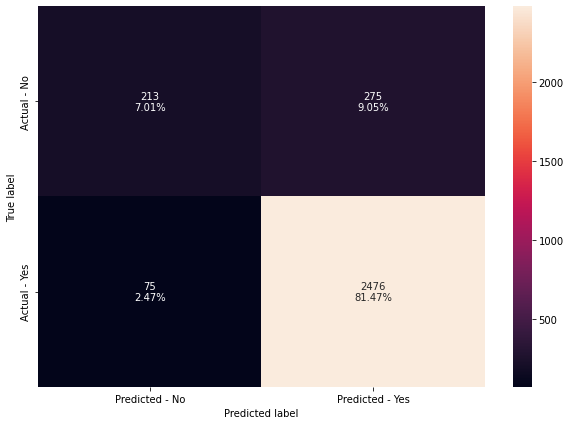

In [ ]:
make_confusion_matrix(bagging_lr,y_test)

**Insights**
Bagging classifier with logistic regression as base_estimator is not overfitting the data but the test recall is very low.
Ensemble models are less interpretable than decision tree but bagging classifier is even less interpretable than random forest. It does not even have a feature importance attribute.

## Model building - Oversampled data

In [ ]:
# Imblearn libary is used to handle imbalanced data
!pip install imblearn --user

!pip install imbalanced-learn --user
# To undersample and oversample the data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
# Fit SMOTE on train data(Synthetic Minority Oversampling Technique)
sm = SMOTE(sampling_strategy=0.4, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(x_train, y_train)

In [ ]:
print("Before OverSampling, count of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, count of label '0': {} \n".format(sum(y_train == 0)))

print("After OverSampling, count of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, count of label '0': {} \n".format(sum(y_train_over == 0)))

print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, count of label '1': 5949
Before OverSampling, count of label '0': 1139 

After OverSampling, count of label '1': 5949
After OverSampling, count of label '0': 2379 

After OverSampling, the shape of train_X: (8328, 23)
After OverSampling, the shape of train_y: (8328,) 



Let's train a ***decision tree classifier*** using the oversampled data

In [ ]:
dt_model_over = DecisionTreeClassifier(criterion = 'entropy' )
# training the decision tree model with oversampled training set
dt_model_over.fit(X_train_over, y_train_over)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
# Predicting the target for train and validation set
pred_train = dt_model_over.predict(X_train_over)
pred_val = dt_model_over.predict(x_train)

In [ ]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train_over, pred_train))
print(recall_score(y_train, pred_val))

1.0
1.0


Text(42.0, 0.5, 'Actual Values')

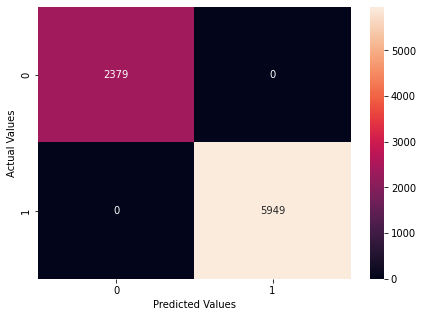

In [ ]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Let's train a ***Bagging classifier*** using the oversampled data

In [ ]:
bagging_estimator_over=BaggingClassifier(random_state=1)
bagging_estimator_over.fit(X_train_over, y_train_over)

BaggingClassifier(random_state=1)

In [ ]:
# Predicting the target for train and validation set
pred_train = bagging_estimator_over.predict(X_train_over)
pred_val = bagging_estimator_over.predict(x_train)

In [ ]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train_over, pred_train))
print(recall_score(y_train, pred_val))

0.9969742813918305
0.9969742813918305


Text(42.0, 0.5, 'Actual Values')

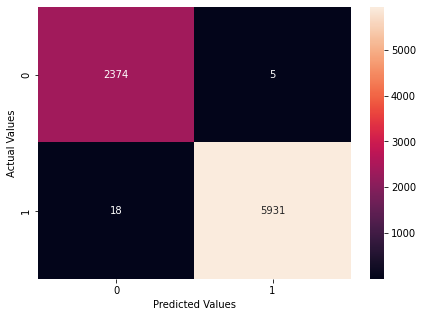

In [ ]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Let's train a ***Random Forest Estimator*** using the oversampled data

In [ ]:
rf_estimator_over=RandomForestClassifier(random_state=1)
rf_estimator_over.fit(X_train_over, y_train_over)

RandomForestClassifier(random_state=1)

In [ ]:
# Predicting the target for train and validation set
pred_train = rf_estimator_over.predict(X_train_over)
pred_val = rf_estimator_over.predict(x_train)

In [ ]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train_over, pred_train))
print(recall_score(y_train, pred_val))

1.0
1.0


Text(42.0, 0.5, 'Actual Values')

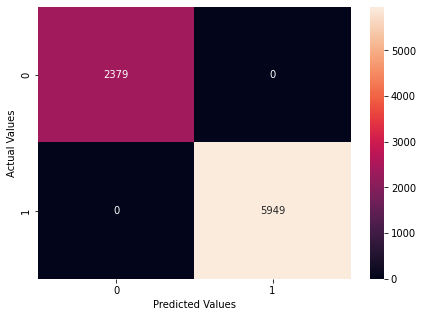

In [ ]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Let's train a ***Logistic regression Estimator*** using the oversampled data



In [ ]:
model_lr_over = LogisticRegression(solver="liblinear", random_state=1)
model_lr_over.fit(X_train_over, y_train_over)

LogisticRegression(random_state=1, solver='liblinear')

In [ ]:
# Predicting the target for train and validation set
pred_train = model_lr_over.predict(X_train_over)
pred_val = model_lr_over.predict(x_train)

In [ ]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train_over, pred_train))
print(recall_score(y_train, pred_val))

0.9144394015800975
0.9144394015800975


Text(42.0, 0.5, 'Actual Values')

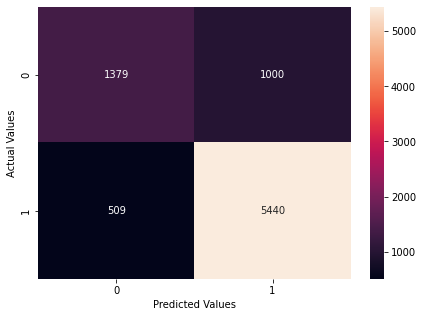

In [ ]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Let's train a ***Boosting Estimator*** using the oversampled data

In [ ]:
abc_over = AdaBoostClassifier(random_state=1)
abc_over.fit(X_train_over, y_train_over)

AdaBoostClassifier(random_state=1)

In [ ]:
# Predicting the target for train and validation set
pred_train = abc_over.predict(X_train_over)
pred_val = abc_over.predict(x_train)

In [ ]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train_over, pred_train))
print(recall_score(y_train, pred_val))

0.9757942511346445
0.9757942511346445


Text(42.0, 0.5, 'Actual Values')

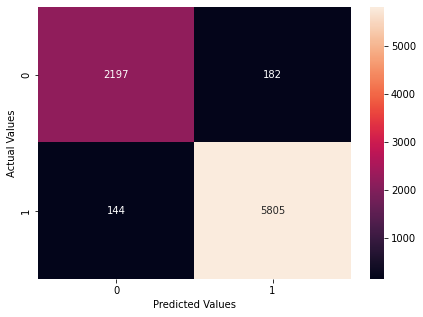

In [ ]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

Let's train a ***Bagging logistic regression*** using the oversampled data

In [ ]:
bagging_lr_over=BaggingClassifier(base_estimator=LogisticRegression(solver='liblinear',random_state=1,max_iter=1000),random_state=1)
bagging_lr_over.fit(X_train_over, y_train_over)

BaggingClassifier(base_estimator=LogisticRegression(max_iter=1000,
                                                    random_state=1,
                                                    solver='liblinear'),
                  random_state=1)

In [ ]:
# Predicting the target for train and validation set
pred_train = bagging_lr_over.predict(X_train_over)
pred_val = bagging_lr_over.predict(x_train)

In [ ]:
# Checking recall score on oversampled train and validation set
print(recall_score(y_train_over, pred_train))
print(recall_score(y_train, pred_val))

0.9204908387964363
0.9204908387964363


Text(42.0, 0.5, 'Actual Values')

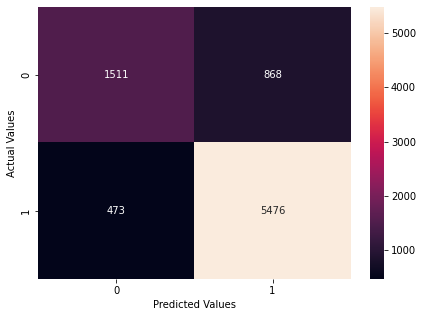

In [ ]:
# Confusion matrix for oversampled train data
cm = confusion_matrix(y_train_over, pred_train)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="g")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

## Undersampling train data using Random Undersample

In [ ]:
# fit random under sampler on the train data
rus = RandomUnderSampler(random_state=1, sampling_strategy = 1)
X_train_un, y_train_un = rus.fit_resample(x_train, y_train)

In [ ]:
print("Before Under Sampling, count of label '1': {}".format(sum(y_train == 1)))
print("Before Under Sampling, count of label '0': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, count of label '1': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, count of label '0': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, count of label '1': 5949
Before Under Sampling, count of label '0': 1139 

After Under Sampling, count of label '1': 1139
After Under Sampling, count of label '0': 1139 

After Under Sampling, the shape of train_X: (2278, 23)
After Under Sampling, the shape of train_y: (2278,) 



Let's train a decision tree classifier using the undersampled data¶


In [ ]:
# training the decision tree model with undersample training set
dt_model_under = DecisionTreeClassifier(criterion = 'entropy' )
dt_model_under.fit(X_train_un, y_train_un)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
scores = recall_score(y_train_un, dt_model_under.predict(X_train_un))
print(scores)

1.0


Let's train a Baggin classifier using the undersampled data

In [ ]:
bagging_estimator_under=BaggingClassifier(random_state=1)
bagging_estimator_under.fit(X_train_un, y_train_un)

BaggingClassifier(random_state=1)

In [ ]:
scores = recall_score(y_train_un, bagging_estimator_under.predict(X_train_un))
print(scores)

0.9877085162423178


Let's train random **forest** classifier using the undersampled data

In [ ]:
rf_estimator_under=RandomForestClassifier(random_state=1)
rf_estimator_under.fit(X_train_un, y_train_un)


RandomForestClassifier(random_state=1)

In [ ]:
scores = recall_score(y_train_un, rf_estimator_under.predict(X_train_un))
print(scores)

1.0


Let's train Logistic Regression Model classifier using the undersampled data

In [ ]:
model_lr_under = LogisticRegression(solver="liblinear", random_state=1)
model_lr_under.fit(X_train_un, y_train_un)


LogisticRegression(random_state=1, solver='liblinear')

In [ ]:
scores = recall_score(y_train_un, model_lr_under.predict(X_train_un))
print(scores)

0.8314310798946444


Let's train Boosting Model classifier using the undersampled data

In [ ]:
abc_under = AdaBoostClassifier(random_state=1)
abc_under.fit(X_train_un, y_train_un)

AdaBoostClassifier(random_state=1)

In [ ]:
scores = recall_score(y_train_un, abc_under.predict(X_train_un))
print(scores)

0.9385425812115891


Let's train bagging logistic regression classifier using the undersampled data

In [ ]:
bagging_lr_under=BaggingClassifier(base_estimator=LogisticRegression(solver='liblinear',random_state=1,max_iter=1000),random_state=1)
bagging_lr_under.fit(X_train_un, y_train_un)

BaggingClassifier(base_estimator=LogisticRegression(max_iter=1000,
                                                    random_state=1,
                                                    solver='liblinear'),
                  random_state=1)

In [ ]:
scores = recall_score(y_train_un, bagging_lr_under.predict(X_train_un))
print(scores)

0.8235294117647058


## Tuned Models

I am gonna tune Descision tree and random forest estimators with oversampling the data. They provide 0 mistake in prediction.

### **Decision Tree Tuned**

In [ ]:
from sklearn.metrics.cluster import entropy
# Choose the type of classifier.
dt_tuned = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {'max_depth': [5,10,15,None],
              'criterion': ['gini','entropy'],
              'splitter':['best','random']

             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(dt_tuned, parameters, scoring='recall',cv=3)
grid_obj = grid_obj.fit(x_test, y_test)

# Set the clf to the best combination of parameters
dt_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dt_tuned.fit(x_test, y_test)
print(dt_tuned.max_depth,dt_tuned.criterion,dt_tuned.splitter)

5 gini random


In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
dt_estimator_tuned_score=get_metrics_score(dt_tuned)

Accuracy on training set :  0.8707674943566591
Accuracy on test set :  0.8775913129318855
Recall on training set :  0.9736090099176332
Recall on test set :  0.9784398275186201
Precision on training set :  0.8841398259807663
Precision on test set :  0.8873089228581585


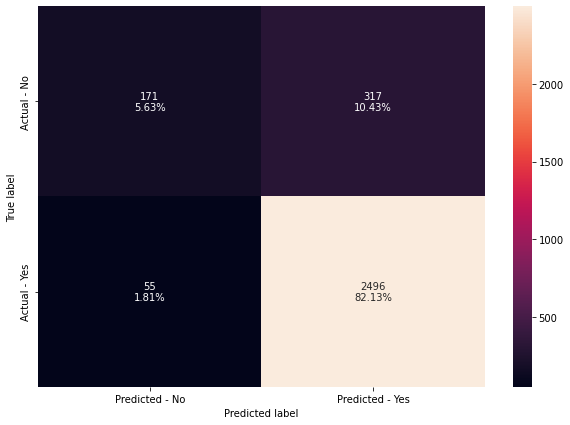

In [ ]:
make_confusion_matrix(dt_tuned,y_test)

### **Bagging Modeld Tuned**

In [ ]:
# Choose the type of classifier.
bagging_estimator_tuned = BaggingClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {'max_samples': [0.7,0.8,0.9,1],
              'max_features': [0.7,0.8,0.9,1],
              'n_estimators' : [10,20,30,40,50],
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)
# Fit the best algorithm to the data.
bagging_estimator_tuned.fit(x_train, y_train)

BaggingClassifier(random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
bagging_estimator_tuned_score=get_metrics_score(bagging_estimator_tuned)

Accuracy on training set :  0.9976015801354402
Accuracy on test set :  0.9585389930898321
Recall on training set :  0.9979828542612204
Recall on test set :  0.9772638181105449
Precision on training set :  0.9991585324806462
Precision on test set :  0.9734478719250292


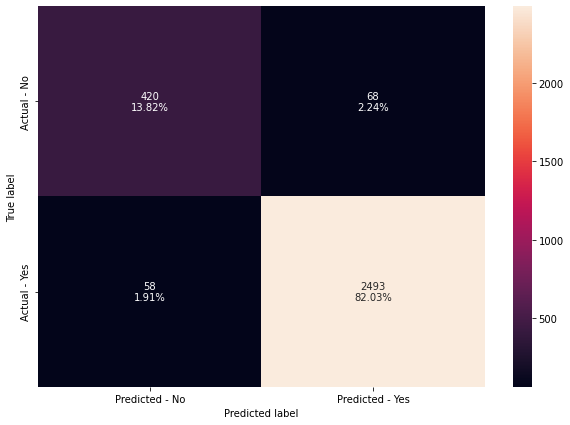

In [ ]:
make_confusion_matrix(bagging_estimator_tuned,y_test)

**Insights**
We can see that train accuracy and recall for the bagging classifier have increased slightly after hyperparameter tuning but the test recall has decreased.
The model is overfitting the data, as train accuracy and recall are much higher than the test accuracy and test recall.
The confusion matrix shows that the model is better at identifying non-defaulters as compared to defaulters.

### Random Forest Tuned

In [ ]:
# Choose the type of classifier.
rf_estimator_tuned = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {"n_estimators": [30,50,70],
    "min_samples_leaf": np.arange(5, 10),
    "max_features": np.arange(0.2, 0.7, 0.1),
    "max_samples": np.arange(0.3, 0.7, 0.1),
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_estimator_tuned.fit(x_train, y_train)

RandomForestClassifier(max_features=0.2, max_samples=0.3, min_samples_leaf=6,
                       n_estimators=70, random_state=1)

In [ ]:
#Using above defined function to get accuracy, recall and precision on train and test set
rf_estimator_tuned_score=get_metrics_score(rf_estimator_tuned)

Accuracy on training set :  0.9509029345372461
Accuracy on test set :  0.9325435998683778
Recall on training set :  0.9920995125231131
Recall on test set :  0.9886319090552724
Precision on training set :  0.9514750926970821
Precision on test set :  0.9347664936990363


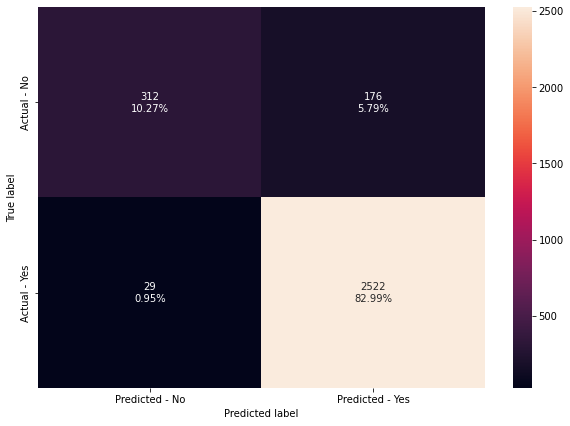

In [ ]:
make_confusion_matrix(rf_estimator_tuned,y_test)

**Insights**
We can see that random forest's performance has increased as compared to the random forest model with default parameters.
Model is slightly overfitting the data but not as much as the tuned bagging classifier.
The test recall is still very low. This means that the model is not good at identifying defaulters which is our primary aim here.

## Productionize the model


Sklearn’s Pipeline integrates all the components to deliver the model.

In [ ]:
# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

In [ ]:
# read the data agin for pipline methodology.
pipeData = pd.read_csv("BankChurners.csv")

In [ ]:
# Separate target variable and other variables
X = pipeData.drop(columns="Attrition_Flag")
Y = pipeData["Attrition_Flag"]

In [ ]:
X["Income_Category"].replace("abc", np.nan, inplace=True)

In [ ]:
# CLIENTNUM will not add value to the modeling, because it is not a computational variable. It will be dropped
X.drop(["CLIENTNUM"], axis=1, inplace=True)

In [ ]:
#Encoding Existing and Attrited customers to 0 and 1 of Y data set ( predicting feature)
Y.replace("Existing Customer", 0, inplace=True)
Y.replace("Attrited Customer", 1, inplace=True)

In [ ]:
# Splitting the data into train and test data sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)
print(X_train.shape, X_test.shape)

(7088, 19) (3039, 19)


In [ ]:
# List of numerical variables
nfeatures = ['Customer_Age', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

# creating a transformer for numerical variables, It will apply simple imputer on numerical variables
ntransformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

# List of categorical variables
cfeatures = ['Gender','Dependent_count', 'Education_Level', 'Marital_Status','Income_Category', 'Card_Category']

# Do transforming for categorical variables, It will apply simple imputer,
#then do one hot encoding for categorical variables
ctransformer = Pipeline( steps=[ ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")), ])

# Join categorical and numerical transformer using a column transformer
preprocessor = ColumnTransformer( transformers=[ ("num", ntransformer, nfeatures), ("cat", ctransformer, cfeatures), ],
    remainder="drop",)

In [ ]:
# Creating pipeline with hyperparameters
model = Pipeline( steps=[
        ("pre", preprocessor),
        ("GBM", GradientBoostingClassifier(
                random_state=1,
                subsample=0.7,
                n_estimators=125,
                max_features=0.7,
                learning_rate=0.2,
                init=AdaBoostClassifier(random_state=1), ), ), ])
# apply the model on the training data set
model.fit(X_train, Y_train)

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Customer_Age',
                                                   'Months_on_book',
                                                   'Total_Relationship_Count',
                                                   'Months_Inactive_12_mon',
                                                   'Contacts_Count_12_mon',
                                                   'Credit_Limit',
                                                   'Total_Revolving_Bal',
                                                   'Avg_Open_To_Buy',
                                                   'Total_Amt_Chng_Q4_Q1',
                                                   'Total_Trans_Amt',
             

In [ ]:
##  Function to calculate different metric scores of the model - Accuracy, Recall and Precision
def get_metrics_score_pipline(model,flag=True):
    '''
    model : classifier to predict values of X

    '''
    # defining an empty list to store train and test results
    score_list=[]

    #Predicting on train and tests
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    #Accuracy of the model
    train_acc = model.score(X_train,Y_train)
    test_acc = model.score(X_test,Y_test)

    #Recall of the model
    train_recall = metrics.recall_score(Y_train,pred_train)
    test_recall = metrics.recall_score(Y_test,pred_test)

    #Precision of the model
    train_precision = metrics.precision_score(Y_train,pred_train)
    test_precision = metrics.precision_score(Y_test,pred_test)

    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision))

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print("Accuracy on training set : ",model.score(X_train,Y_train))
        print("Accuracy on test set : ",model.score(X_test,Y_test))
        print("Recall on training set : ",metrics.recall_score(Y_train,pred_train))
        print("Recall on test set : ",metrics.recall_score(Y_test,pred_test))
        print("Precision on training set : ",metrics.precision_score(Y_train,pred_train))
        print("Precision on test set : ",metrics.precision_score(Y_test,pred_test))

    return score_list # returning the list with train and test scores

In [ ]:
## Function to create confusion matrix
def make_confusion_matrix_pipline(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
get_metrics_score_pipline(model)

Accuracy on training set :  0.9885722347629797
Accuracy on test set :  0.9759789404409345
Recall on training set :  0.9499561018437226
Recall on test set :  0.9057377049180327
Precision on training set :  0.9783001808318263
Precision on test set :  0.9424307036247335


[0.9885722347629797,
 0.9759789404409345,
 0.9499561018437226,
 0.9057377049180327,
 0.9783001808318263,
 0.9424307036247335]

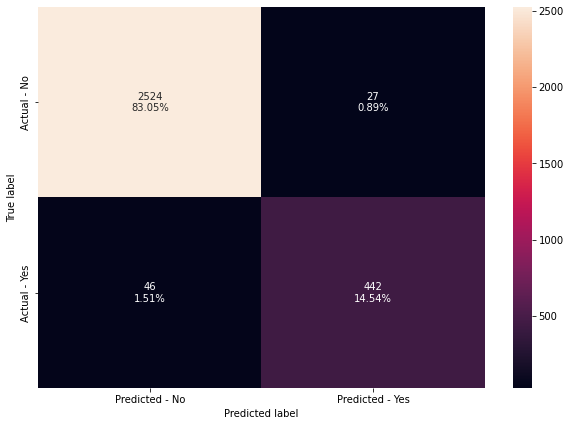

In [ ]:
make_confusion_matrix_pipline(model,Y_test)

##Model Comparsion

In [ ]:
# training performance comparison

# defining list of models
models = [rf_estimator_tuned, bagging_estimator_tuned, dt_tuned,
        bagging_lr_under, dt_model_over, bagging_estimator_over]

# defining empty lists to add train and test results
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train= []
precision_test = []

# looping through all the models to get the accuracy, precall and precision scores
for model in models:
    j = get_metrics_score(model,False)
    acc_train.append(np.round(j[0],2))
    acc_test.append(np.round(j[1],2))
    recall_train.append(np.round(j[2],2))
    recall_test.append(np.round(j[3],2))
    precision_train.append(np.round(j[4],2))
    precision_test.append(np.round(j[5],2))

comparison_frame = pd.DataFrame({'Model':['Tuned Random Forest trained with original data data','Tuned Bagging Estimator trained with original data',
                                        'Tuned Decision Tree trained with original data', 'Bagging Logistic regressiontrained with Undersample data',
                                         'Decision Tree with oversample data','Bagging estimator trained with oversample data'],
                                          'Train_Accuracy': acc_train,'Test_Accuracy': acc_test,
                                          'Train_Recall':recall_train,'Test_Recall':recall_test,
                                          'Train_Precision':precision_train,'Test_Precision':precision_test})

comparison_frame


,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision
0,Tuned Random Forest trained with original data...,0.95,0.93,0.99,0.99,0.95,0.93
1,Tuned Bagging Estimator trained with original ...,1.00,0.96,1.00,0.98,1.00,0.97
2,Tuned Decision Tree trained with original data,0.87,0.88,0.97,0.98,0.88,0.89
3,Bagging Logistic regressiontrained with Unders...,0.84,0.84,0.84,0.85,0.97,0.96
4,Decision Tree with oversample data,1.00,0.94,1.00,0.96,1.00,0.97
5,Bagging estimator trained with oversample data,1.00,0.95,1.00,0.96,1.00,0.98


#Conclusion

I build a predictive model that can do the followings:
- Identify customers who are at the risk of attrition.
- Find the key causes that drive attrition.
- Can give suitable actions to set suitable policies for customers.

Feature affects attrition are:
- Total_Trans_Ct
- Total_Revolving_Bal
- Total_Trans_Amt
- Total_Relationship_Count


* Female customers should be the target customers for marketing campaign as they make more and transactions. Their credit limit is little so expand the credit limit for them can profit the bank. Also, we have more female than male.

* Highest attrition is among the customers who do communication to the bank. This means the bank is not able to resolve the problems faced by customers and then leading to  attrition.

In [ ]:
%%shell
jupyter nbconvert --to html/content/Credit_Card_Users_Churn_Prediction-3.ipynb

[NbConvertApp] Converting notebook /content/Credit_Card_Users_Churn_Prediction.ipynb to html
[NbConvertApp] Writing 4970960 bytes to /content/Credit_Card_Users_Churn_Prediction.html
